In [30]:
import pandas as pd

df=pd.read_csv("spam.csv",encoding="latin-1")

print("Loaded")

Loaded


In [31]:
print(df.head(5))
print(df.columns)

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')


In [6]:
print(df.describe())
print(df.shape)
print(df.info())

          v1                      v2  \
count   5572                    5572   
unique     2                    5169   
top      ham  Sorry, I'll call later   
freq    4825                      30   

                                               Unnamed: 2  \
count                                                  50   
unique                                                 43   
top      bt not his girlfrnd... G o o d n i g h t . . .@"   
freq                                                    3   

                   Unnamed: 3 Unnamed: 4  
count                      12          6  
unique                     10          5  
top      MK17 92H. 450Ppw 16"    GNT:-)"  
freq                        2          2  
(5572, 5)
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  

In [7]:
print(df.isnull().sum())

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


In [8]:
print(df.duplicated().sum())

403


In [32]:
df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)
print(df.isnull().sum())

v1    0
v2    0
dtype: int64


In [28]:
df=df.drop_duplicates()
print(df.duplicated().sum())

0


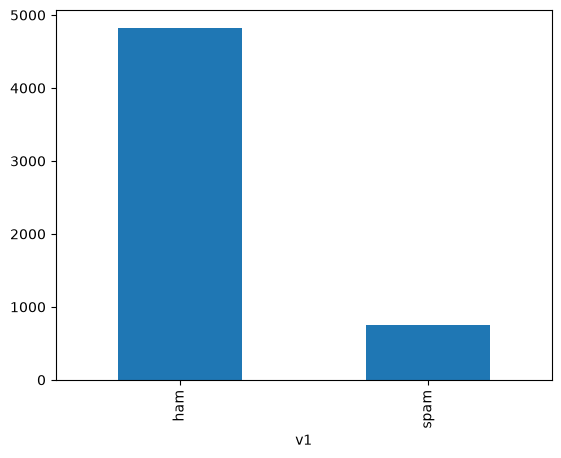

In [37]:
import matplotlib.pyplot as plt

df["v1"].value_counts().plot(kind="bar")
plt.show()

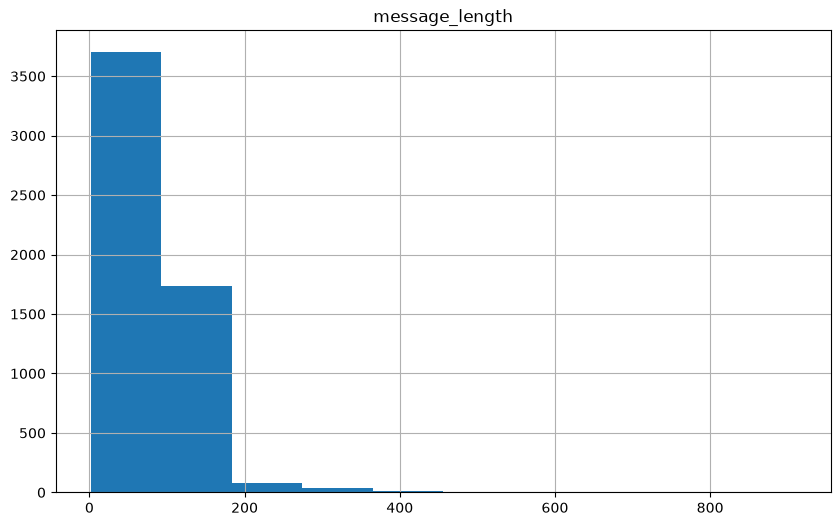

In [35]:
df.hist(figsize=(10,6))
plt.show()


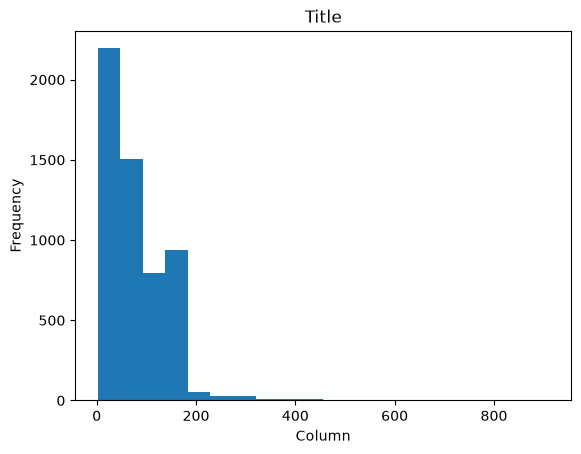

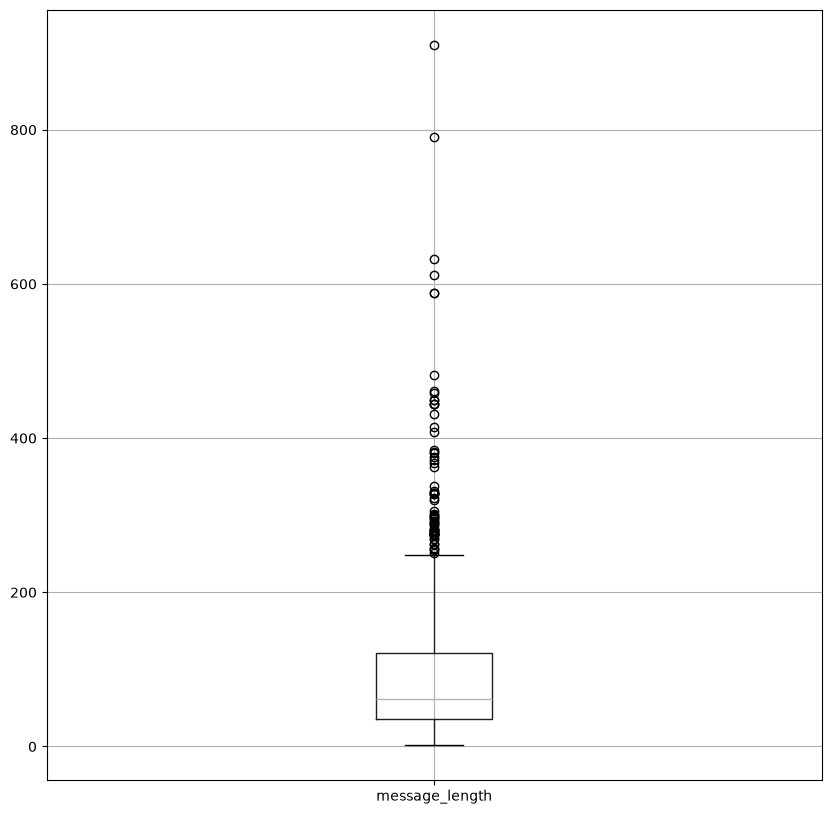

In [42]:
plt.figure(figsize=(10,10))
df.boxplot()
plt.show()

In [41]:
print(df.columns)

Index(['v1', 'v2', 'message_length'], dtype='str')


In [51]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer


tfidf=TfidfVectorizer()

le=LabelEncoder()
df["v1"]=le.fit_transform(df["v1"])
x=tfidf.fit_transform(df["v2"])
y=df["v1"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(4457, 8672)
(4457,)
(1115, 8672)
(1115,)


In [54]:
print(x_train[:5])


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 72 stored elements and shape (5, 8672)>
  Coords	Values
  (0, 4087)	0.1363554359676013
  (0, 3831)	0.22373410370588745
  (0, 5367)	0.1760662062543487
  (0, 7253)	0.2129859169630051
  (0, 5223)	0.14915391012997223
  (0, 4939)	0.14378067065478475
  (0, 7627)	0.1250021552728397
  (0, 5525)	0.15967788028036542
  (0, 1260)	0.17167311365375632
  (0, 5609)	0.18841033141508542
  (0, 3711)	0.27594587972305035
  (0, 1976)	0.27594587972305035
  (0, 6598)	0.26651308736220675
  (0, 8604)	0.28349984119511407
  (0, 5241)	0.3507533622715513
  (0, 1595)	0.38297119137367513
  (0, 5113)	0.3641249694942899
  (1, 8032)	0.13083310165592346
  (1, 3308)	0.1061612084412178
  (1, 4206)	0.09988250637087062
  (1, 5764)	0.1848619807453563
  (1, 5606)	0.1546552298494583
  (1, 7621)	0.11297608766952633
  (1, 5627)	0.17957829414928506
  (1, 5477)	0.11026168101528257
  :	:
  (3, 5871)	0.4440569158293342
  (3, 1719)	0.45641786095533354
  (3, 6983)	0.49481446

In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model=DecisionTreeClassifier()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.967713004484305


In [56]:
from  sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=100000)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9632286995515695


In [57]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred)
print(cm)

[[965   0]
 [ 41 109]]


In [64]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

select = SelectKBest(score_func=f_classif, k=10)

x_new = select.fit_transform(x_train, y_train)

feature_names = tfidf.get_feature_names_out()

print("Selected Features:")
print(feature_names[select.get_support()])

Selected Features:
['150p' '50' 'claim' 'free' 'mobile' 'prize' 'stop' 'txt' 'uk' 'www']


C:\Users\Naveenkumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0

In [65]:
feature_names = tfidf.get_feature_names_out()

selected_features = feature_names[select.get_support()]

print(selected_features)

['150p' '50' 'claim' 'free' 'mobile' 'prize' 'stop' 'txt' 'uk' 'www']
